# Week 7 — Strategic and Economic Network Formation

In this lab we explore how networks can arise from **individual incentives** rather than being imposed externally. The main ideas come from **strategic network formation models**, where agents decide whether to form or sever links based on costs and benefits. We will explore three main ideas:
1. Costs and benefits of links
   - Direct links provide benefits but are costly to create and maintain
   - Indirect connections can also generate value (externalities)
2. Connections Model (Jackson & Wolinsky)
   - Benefits decay with distance in the network
   - Different parameter values generate different network structures (empty network, star, dense networks)
3. Pairwise stability: a network is pairwise stable if no agent wants to delete a link and no pair of agents wants to add one
4. Connection to the concept of **small worlds**, where networks simultaneously have:
- **Short path lengths** (easy to reach any node from any other)
- **High clustering** (large local grouping)
- **Sparsity** (few number of edges)

These structures often arise in social and collaboration networks. Social networks are those where individuals represent nodes and social links are classified as edges, whereas collaboration can arise between any set of agents and is inherently undirected.

In [43]:
# Import necessary libraries
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# Visualization function for graphs
def plot_graph(g, title="Network", layout_algorithm="fr"):
    _, ax = plt.subplots(figsize=(6, 6))
    ig.plot(
        g,
        target=ax,
        layout=layout_algorithm,
        vertex_size=25,
        vertex_color="indianred",
        vertex_label=list(range(g.vcount())),
        edge_width=1.5,
        bbox=(400,400),
        margin=30
    )
    ax.set_title(title)
    plt.show()

## Costs and benefits of linking

### Simple example

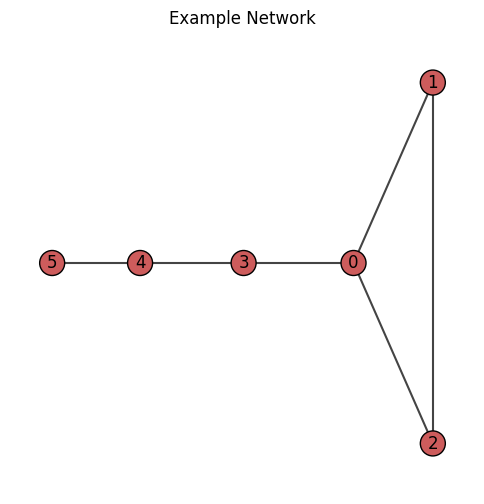

In [44]:
# Create a simple deterministic network
g = ig.Graph()
n = 6
g.add_vertices(n)
edges = [
    (0,1),(0,2),(0,3),
    (1,2),
    (3,4),
    (4,5)
]
g.add_edges(edges)
plot_graph(g, "Example Network")

Consider the following questions:
1. Which nodes are most central?
2. What is the longest distance between two nodes?
3. Which nodes benefit most from the network?

In [45]:
# Distance and Indirect Connections
distances = g.distances()
print("Distance matrix:")
print(np.array(distances))

avg_path = g.average_path_length()
print("Average path length:", avg_path)

Distance matrix:
[[0 1 1 1 2 3]
 [1 0 1 2 3 4]
 [1 1 0 2 3 4]
 [1 2 2 0 1 2]
 [2 3 3 1 0 1]
 [3 4 4 2 1 0]]
Average path length: 2.066666666666667


## Connections Model

Utility function of node $i \in \mathcal{N}$ from graph $\mathcal{G}$:
$$
    U_i(\mathcal{G}) = \sum_{j \ne i} \delta^{d(i,j)} - c \cdot d_i(\mathcal{G})
$$
where:
- $d(i,j)$ = network distance between nodes $i$ and $j$ in graph $\mathcal{G}$
- $d_i$ = degree of node $i$ in graph $\mathcal{G}$
- $c$ = link cost (constant)
- $\delta \in [0, 1)$ = decay parameter (linking benefit)

In [54]:
# Define a function that evaluates this utility for any graph G and parameters c and delta
def connections_utility(g, delta=0.6, cost=0.2):
    # Extract information on the network: nodes, distances and degrees
    n_nodes = g.vcount()
    distances = g.distances()
    degrees = g.degree()

    # Calculate utilities using a loop over nodes, summing over benefits and connections
    utilities = np.zeros(n_nodes)
    for i in range(n_nodes):
        # Calculate total benefits from direct and indirect connections
        benefit = 0
        for j in np.delete(range(n_nodes), i):
            if distances[i][j] < np.inf:
                benefit += delta ** distances[i][j]

        # Calculate total cost from direct connections. Utility is benefit minus costs
        cost_term = cost * degrees[i]
        utilities[i] = benefit - cost_term
    return utilities

1.7759999999999994
Node 0: utility 1.776
Node 1: utility 1.506
Node 2: utility 1.506
Node 3: utility 1.88
Node 4: utility 1.592
Node 5: utility 1.235


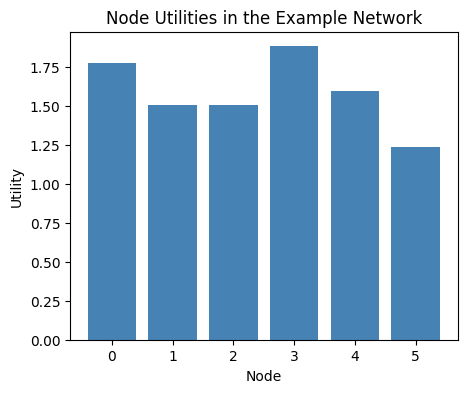

In [62]:
# Evaluate utilities in the example network
delta = 0.6
cost = 0.2
utilities = connections_utility(g, delta=delta, cost=cost)

# Utility for each node
print(delta**1 + delta**1 + delta**1 + delta**2 + delta**3 - cost * 3)
for i,u in enumerate(utilities):
    print(f"Node {i}: utility {round(u,3)}")

# Visualize as a bar graph
plt.figure(figsize=(5,4))
plt.bar(range(n), utilities, color="steelblue")
plt.xlabel("Node")
plt.ylabel("Utility")
plt.title("Node Utilities in the Example Network")
plt.show()

## Pairwise stability

Let us consider four potential networks that can arise:
1. Complete network
2. Empty network
3. Line network
4. Star network

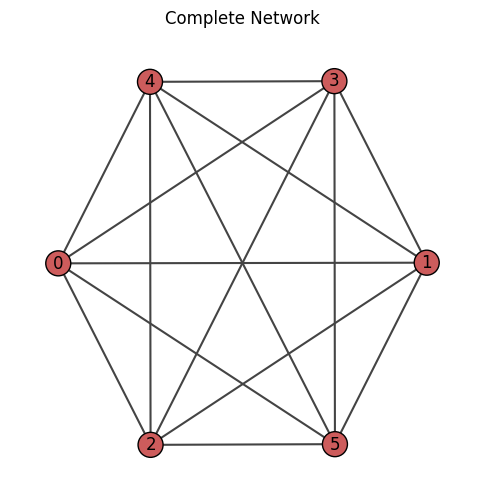

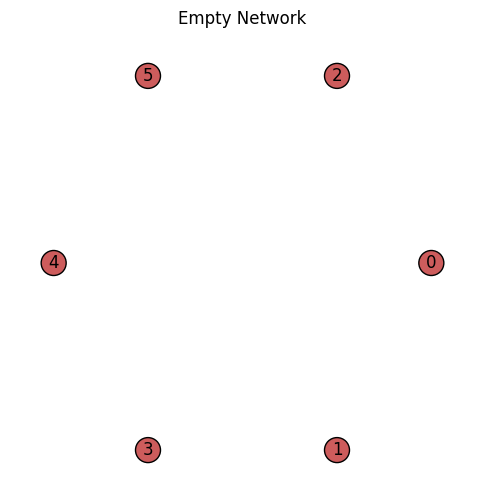

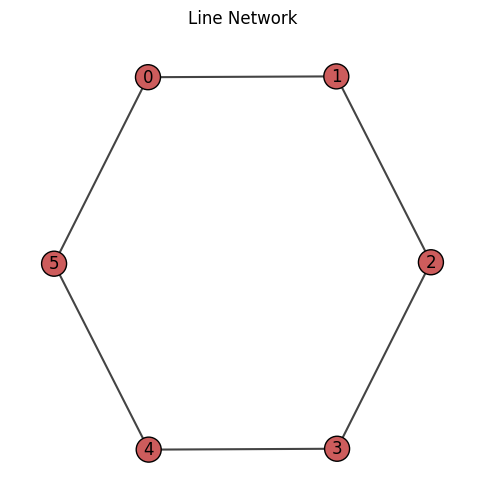

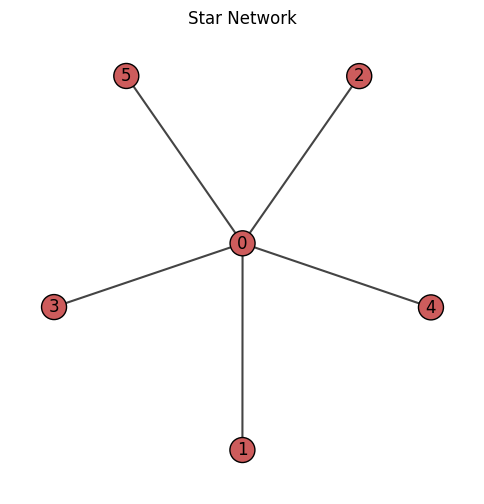

Utilities in Complete Network: [0. 0. 0. 0. 0. 0.]
Utilities in Empty Network: [0. 0. 0. 0. 0. 0.]
Utilities in Line Network: [0.936 0.936 0.936 0.936 0.936 0.936]
Utilities in Star Network: [0.   1.44 1.44 1.44 1.44 1.44]


Text(0.5, 1.0, 'Star Network')

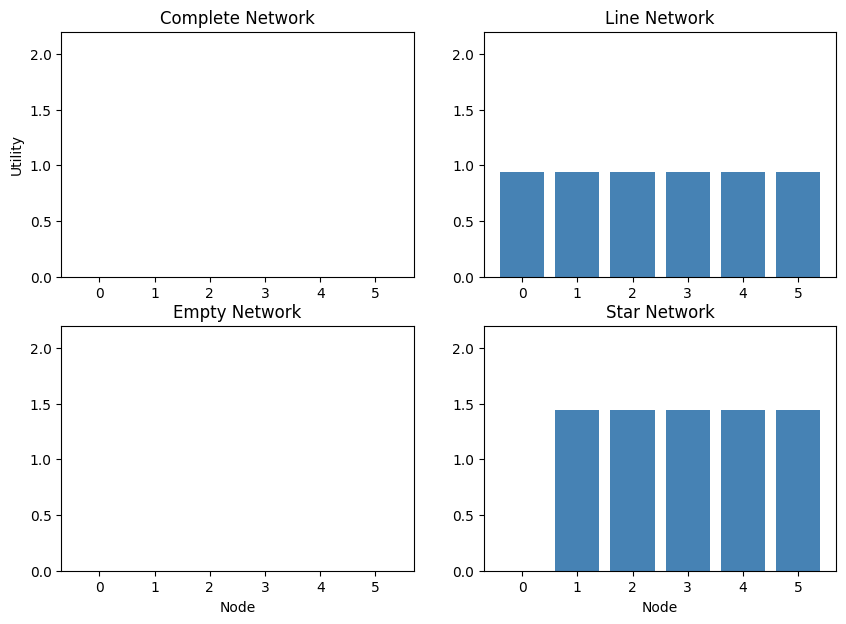

In [6]:
# Visualize the three potential networks: complete, empty and star
g_complete = ig.Graph.Full(n)
g_empty = ig.Graph(n)
g_line = ig.Graph.Lattice([n], circular=True)
g_star = ig.Graph.Star(n)
plot_graph(g_complete, "Complete Network")
plot_graph(g_empty, "Empty Network")
plot_graph(g_line, "Line Network")
plot_graph(g_star, "Star Network")

# Calculate utilities for each potential network (complete, empty and star)
utilities_complete = connections_utility(g_complete, delta=delta, cost=cost)
utilities_empty = connections_utility(g_empty, delta=delta, cost=cost)
utilities_line = connections_utility(g_line, delta=delta, cost=cost)
utilities_star = connections_utility(g_star, delta=delta, cost=cost)

# Print and visualize utilities for each potential network
print("Utilities in Complete Network:", np.round(utilities_complete, 3))
print("Utilities in Empty Network:", np.round(utilities_empty, 3))
print("Utilities in Line Network:", np.round(utilities_line, 3))
print("Utilities in Star Network:", np.round(utilities_star, 3))
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
plt.bar(range(n), utilities_complete, color="steelblue")
plt.ylim(0, 2.2)
plt.ylabel("Utility")
plt.title("Complete Network")
plt.subplot(2,2,2)
plt.bar(range(n), utilities_line, color="steelblue")
plt.ylim(0, 2.2)
plt.title("Line Network")
plt.subplot(2,2,3)
plt.bar(range(n), utilities_empty, color="steelblue")
plt.ylim(0, 2.2)
plt.xlabel("Node")
plt.title("Empty Network")
plt.subplot(2,2,4)
plt.bar(range(n), utilities_star, color="steelblue")
plt.ylim(0, 2.2)
plt.xlabel("Node")
plt.title("Star Network")

In [7]:
# Test for pairwise stability: direct check of additions and removals
def link_deletion_incentives(g, delta=0.6, cost=0.2):
    # Calculate current utility to compare after deletion
    current_utility = connections_utility(g, delta, cost)
    deletions = []

    # Run a loop over all edges and remove them
    for e in g.es:
        i, j = e.tuple
        g_removed = g.copy()
        g_removed.delete_edges([(i,j)])

        # Calculate new utility and test whether it has improved for any of the links
        new_utility = connections_utility(g_removed, delta, cost)
        if new_utility[i] > current_utility[i] or new_utility[j] > current_utility[j]:
            deletions.append((i,j))
    return deletions

def link_addition_incentives(g, delta=0.6, cost=0.2):
    # Calculate current utility to compare after addition
    n = g.vcount()
    current_utility = connections_utility(g, delta, cost)
    additions = []

    # Loop over all possible edges and test whether adding them improves utility
    for i in range(n):
        for j in range(i+1,n):
            if not g.are_adjacent(i,j): # Do not test if link already present
                g_added = g.copy()
                g_added.add_edge(i,j)

                # Calculate new utility and test whether it has improved for any of the links
                new_utility = connections_utility(g_added, delta, cost)
                if new_utility[i] > current_utility[i] and new_utility[j] > current_utility[j]:
                    additions.append((i,j))
    return additions

def test_pairwise_stability(g, delta=0.6, cost=0.2):
    # Run both addition and deletion tests and print results
    additions = link_addition_incentives(g, delta, cost)
    deletions = link_deletion_incentives(g, delta, cost)
    print("Links agents want to DELETE:", deletions)
    print("Links agents want to ADD:", additions)

    # Return a final verdict on pairwise stability
    if len(additions) == 0 and len(deletions) == 0:
        print("\nNetwork is PAIRWISE STABLE")
        return True
    else:
        print("\nNetwork is NOT pairwise stable")
        return False

### Stability thresholds for the networks
Jackson & Wolinsky (1996) show that whichever networks end up as pairwise stable depends on the combination of parameters:
- $\delta$ (direct benefit) and
- $c$ (direct cost)
- $\delta^2$ is benefit of an indirect link (two steps away)
- $\Delta \coloneqq \delta - \delta^2$ (difference between direct and indirect linking benefit)

Specifically, they show the following
1. If direct cost is less than the difference between direct and indirect linking $\implies$ **dense networks** form: $c < \Delta$
2. If direct cost is larger than difference between direct and indirect linking but smaller than the direct benefit itself $\implies$ **star networks** form: $\Delta < c < \delta$
3. If direct cost is larger than benefit of direct linking $\implies$ **empty network** forms: $c > \delta$

Additionally, for the link network, consider a link between nodes 1 and 3:
- Benefit of linking 1 and 3 directly: $\delta$
- Benefit of their indirect link with node 2: $\delta^2$
- As $\delta < 1 \implies \delta^2 < \delta$, benefit of direct link is larger than indirect link
- Agents would want to form the link, so line network is not generally pairwise stable
- Can still be stable if ratio of cost to benefit is not large and network size is small

In [8]:
# Test conditions on pairwise stable networks to confirm theoretical results
delta = 0.6
c = 0.2
direct_indirect_diff = delta - delta**2
print("Difference between direct and indirect linking:", direct_indirect_diff)
print("Difference cost and direct linking benefit:", c - delta)
print("Difference cost and marginal linking benefit:", c - direct_indirect_diff)
print("Testing Complete Network:")
test_pairwise_stability(g_complete, delta, c)
print("\nTesting Empty Network:")
test_pairwise_stability(g_empty, delta, c)
print("\nTesting Line Network:")
test_pairwise_stability(g_line, delta, c)
print("\nTesting Star Network:")
test_pairwise_stability(g_star, delta, c)

Difference between direct and indirect linking: 0.24
Difference cost and direct linking benefit: -0.39999999999999997
Difference cost and marginal linking benefit: -0.03999999999999998
Testing Complete Network:
Links agents want to DELETE: []
Links agents want to ADD: []

Network is PAIRWISE STABLE

Testing Empty Network:
Links agents want to DELETE: []
Links agents want to ADD: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]

Network is NOT pairwise stable

Testing Line Network:
Links agents want to DELETE: []
Links agents want to ADD: [(0, 2), (0, 3), (0, 4), (1, 3), (1, 4), (1, 5), (2, 4), (2, 5), (3, 5)]

Network is NOT pairwise stable

Testing Star Network:
Links agents want to DELETE: []
Links agents want to ADD: [(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]

Network is NOT pairwise stable


False

In [9]:
delta = 0.6
c = 0.4
direct_indirect_diff = delta - delta**2
print("Difference between direct and indirect linking:", direct_indirect_diff)
print("Difference cost and direct linking benefit:", c - delta)
print("Difference cost and marginal linking benefit:", c - direct_indirect_diff)
print("Testing Complete Network:")
test_pairwise_stability(g_complete, delta, c)
print("\nTesting Empty Network:")
test_pairwise_stability(g_empty, delta, c)
print("\nTesting Line Network:")
test_pairwise_stability(g_line, delta, c)
print("\nTesting Star Network:")
test_pairwise_stability(g_star, delta, c)

Difference between direct and indirect linking: 0.24
Difference cost and direct linking benefit: -0.19999999999999996
Difference cost and marginal linking benefit: 0.16000000000000003
Testing Complete Network:
Links agents want to DELETE: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
Links agents want to ADD: []

Network is NOT pairwise stable

Testing Empty Network:
Links agents want to DELETE: []
Links agents want to ADD: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]

Network is NOT pairwise stable

Testing Line Network:
Links agents want to DELETE: []
Links agents want to ADD: []

Network is PAIRWISE STABLE

Testing Star Network:
Links agents want to DELETE: []
Links agents want to ADD: []

Network is PAIRWISE STABLE


True

In [10]:
delta = 0.6
c = 0.8
direct_indirect_diff = delta - delta**2
print("Difference between direct and indirect linking:", direct_indirect_diff)
print("Difference cost and direct linking benefit:", c - delta)
print("Difference cost and marginal linking benefit:", c - direct_indirect_diff)
print("Testing Complete Network:")
test_pairwise_stability(g_complete, delta, c)
print("\nTesting Empty Network:")
test_pairwise_stability(g_empty, delta, c)
print("\nTesting Line Network:")
test_pairwise_stability(g_line, delta, c)
print("\nTesting Star Network:")
test_pairwise_stability(g_star, delta, c)

Difference between direct and indirect linking: 0.24
Difference cost and direct linking benefit: 0.20000000000000007
Difference cost and marginal linking benefit: 0.56
Testing Complete Network:
Links agents want to DELETE: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
Links agents want to ADD: []

Network is NOT pairwise stable

Testing Empty Network:
Links agents want to DELETE: []
Links agents want to ADD: []

Network is PAIRWISE STABLE

Testing Line Network:
Links agents want to DELETE: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (0, 5)]
Links agents want to ADD: []

Network is NOT pairwise stable

Testing Star Network:
Links agents want to DELETE: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Links agents want to ADD: []

Network is NOT pairwise stable


False

In [11]:
# Evolution to pairwise stable networks
rng = np.random.default_rng(seed=12345)
def evolve_network(n, delta=0.6, cost=0.2, steps=200):
    # Create empty graph with n nodes
    g = ig.Graph(n)
    g.vs["label"] = list(range(n))

    # Run a loop over total steps to evolve the network at each step
    for _ in range(steps):
        # Choose a pair of nodes at random
        i, j = rng.choice(range(n), size=2, replace=False)
        old_utility = connections_utility(g, delta, cost)
        if g.are_adjacent(i,j):
            # Test whether link (i, j) should be deleted
            g_removed = g.copy()
            g_removed.delete_edges([(i,j)])
            new_utility = connections_utility(g_removed, delta, cost)

            # Delete if utility of removing larger than utility of keeping it for any
            if new_utility[i] > old_utility[i] or new_utility[j] > old_utility[j]:
                g = g_removed
        else:
            # Test whether link (i, j) should be added
            g_added = g.copy()
            g_added.add_edge(i,j)
            new_utility = connections_utility(g_added, delta, cost)
            if new_utility[i] > old_utility[i] and new_utility[j] > old_utility[j]:
                g = g_added
    return g

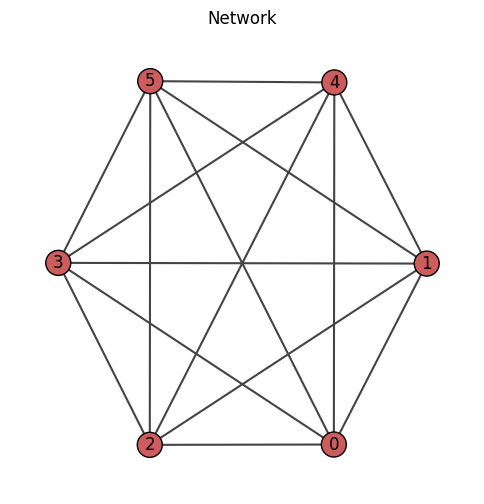

Links agents want to DELETE: []
Links agents want to ADD: []

Network is PAIRWISE STABLE


True

In [12]:
# Run the evolution function and visualize the resulting network
delta = 0.6
cost = 0.2
g_evolved = evolve_network(n, delta, cost)
plot_graph(g_evolved)
test_pairwise_stability(g_evolved, delta, cost)

## Small worlds

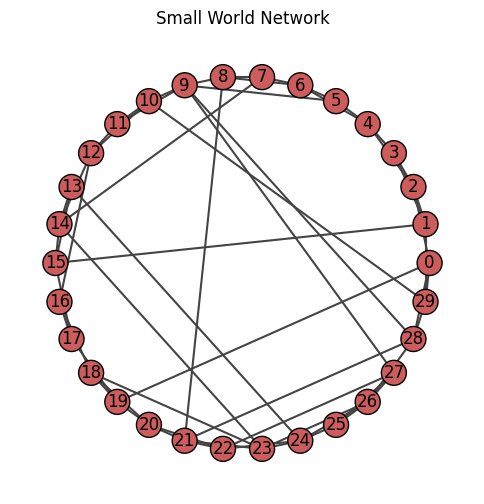

Clustering coefficient: 0.20634920634920634
Average path length: 2.6413793103448278


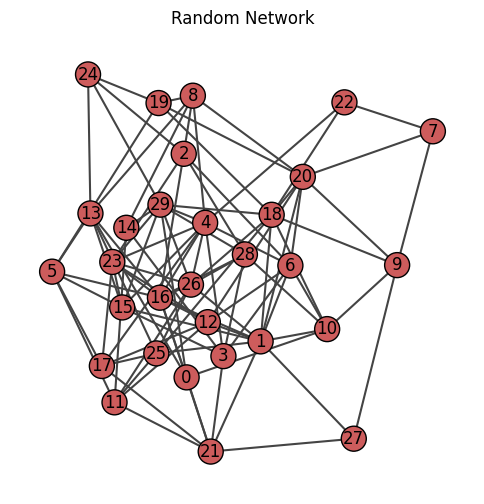

Clustering: 0.22131147540983606
Path length: 1.967816091954023


In [42]:
g_sw = ig.Graph.Watts_Strogatz(
    dim=1,
    size=30,
    nei=2,
    p=0.2
)
plot_graph(g_sw, "Small World Network", layout_algorithm="circle")

# Clustering and path length
clustering = g_sw.transitivity_undirected()
path_length = g_sw.average_path_length()
print("Clustering coefficient:", clustering)
print("Average path length:", path_length)

# Compare to a random graph
g_random = ig.Graph.Erdos_Renyi(n=30, p=0.2)
plot_graph(g_random, "Random Network")
print("Clustering:", g_random.transitivity_undirected())
print("Path length:", g_random.average_path_length())

### Six degrees of separation (with and without clustering)

Average path length: 3.1339195979899497
Diameter: 6
Clustering: 0.030986681163359606


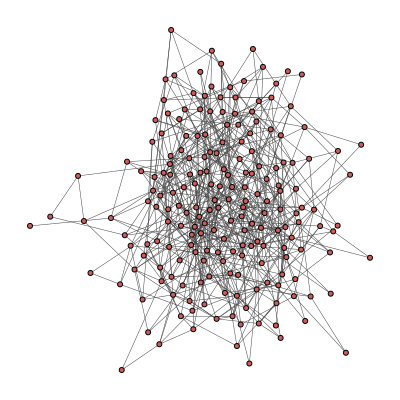

In [14]:
# Large random graph with small path length, diameter but low clustering
g_large = ig.Graph.Erdos_Renyi(n=200, p=0.03)
print("Average path length:", g_large.average_path_length())
print("Diameter:", g_large.diameter())
print("Clustering:", g_large.transitivity_undirected())
ig.plot(g_large,
        vertex_size=5,
        vertex_color="indianred",
        edge_width=0.5,
        bbox=(400,400),
        margin=30
)

Average path length: 3.391005025125628
Diameter: 6
Clustering: 0.600859987929994


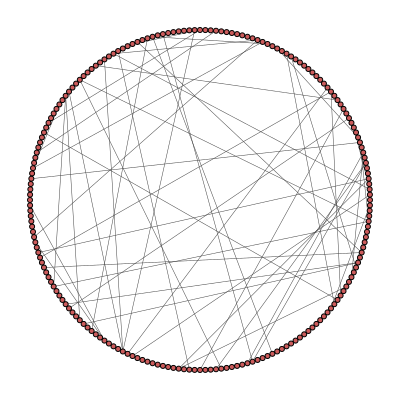

In [22]:
# Watts-Strogatz random graph with small path length, diameter and high clustering
g_sw = ig.Graph.Watts_Strogatz(
    dim=1,
    size=200,
    nei=6,
    p=0.02
)
print("Average path length:", g_sw.average_path_length())
print("Diameter:", g_sw.diameter())
print("Clustering:", g_sw.transitivity_undirected())
ig.plot(g_sw,
        layout="circle",
        vertex_size=5,
        vertex_color="indianred",
        edge_width=0.5,
        bbox=(400,400),
        margin=30
)

## Exercise

1. Create a network of ~10–15 people you know.
2. Add links between people who know each other.
3. Compute:
- degree
- clustering
- path length

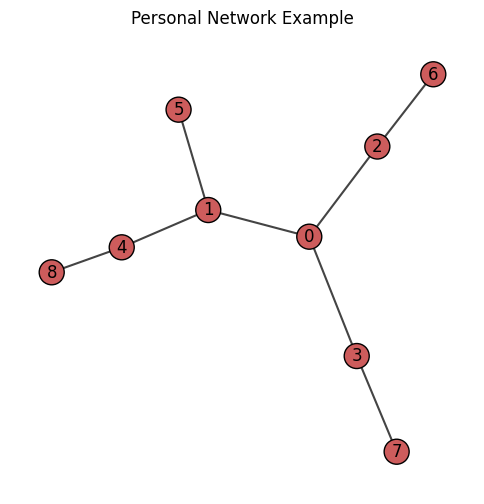

In [16]:
# Example: friendship network

edges = [
("You","A"),
("You","B"),
("You","C"),
("A","D"),
("A","E"),
("B","F"),
("C","G"),
("D","H"),
]

g_social = ig.Graph.TupleList(edges, directed=False)

plot_graph(g_social,"Personal Network Example")